Data Preprocessing 

Importing the Essential Libraries 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense,Dropout
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
import os
import warnings
from tensorflow import keras
from tensorflow.keras import layers
from kerastuner.tuners import RandomSearch
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.model_selection import train_test_split



Data Preprocessing 

Shape of the original dataset: (2947, 563)
Shape of train data is: (2357, 563)
Shape of test data is: (590, 563)
x_train shape: (2357, 561), y_train shape: (2357, 1)
x_test shape: (590, 561), y_test shape: (590, 1)
After encoding: x_test shape: (590, 561), y_test shape: (590,)
x_train shape: (2357, 561), y_train shape: (2357,)
Final preprocessed shapes - x_train: (2357, 561), y_train: (2357,)
x_test: (590, 561), y_test: (590,)


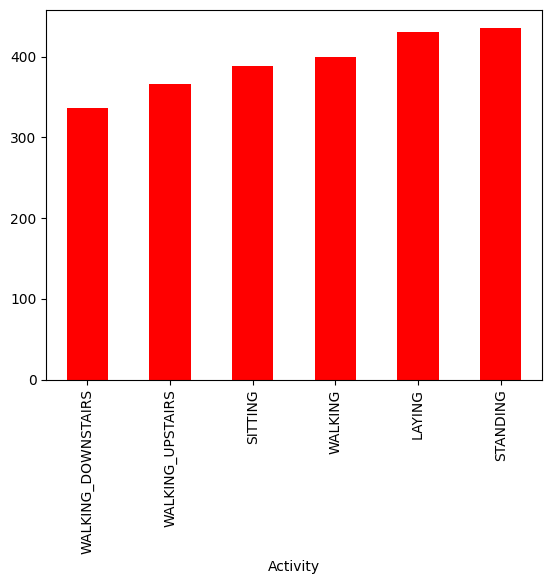

In [4]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Define the path to the original dataset
data_path = "/Users/ayesha/Desktop/HAR_Com774/data/raw/dataset.csv"

# Load the dataset into a pandas DataFrame
dataset = pd.read_csv(data_path)

# Display the shape of the original dataset
print(f"Shape of the original dataset: {dataset.shape}")

# Split the dataset into training and testing sets (80% training, 20% testing)
# 'random_state' is set for reproducibility
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

# Define paths to save the split datasets
train_path = "/Users/ayesha/Desktop/HAR_Com774/data/processed/train.csv"
test_path = "/Users/ayesha/Desktop/HAR_Com774/data/processed/test.csv"

# Save the training and testing sets to the processed directory
train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)

# Display the shapes of the split datasets for verification
print(f"Shape of train data is: {train_data.shape}")
print(f"Shape of test data is: {test_data.shape}")

# Visualize the distribution of 'Activity' column in the training set (Optional)
train_data['Activity'].value_counts().sort_values().plot(kind='bar', color='red')

# Separate features (X) and target labels (y) for training and testing sets
x_train, y_train = train_data.iloc[:, :-2], train_data.iloc[:, -1:]
x_test, y_test = test_data.iloc[:, :-2], test_data.iloc[:, -1:]

# Display the shape of features and labels for verification
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

# Encode the target labels using LabelEncoder
# Converts categorical labels into numeric labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

# Display shapes after encoding
print(f"After encoding: x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")

# Normalize feature data using MinMaxScaler
# This scales all feature values to a range between 0 and 1
scaling_data = MinMaxScaler()
x_train = scaling_data.fit_transform(x_train)
x_test = scaling_data.transform(x_test)

# Final shapes of the preprocessed training and testing data
print(f"Final preprocessed shapes - x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")


Building the Model 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │        35,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,358 (142.02 KB)

 Trainable params: 36,358 (142.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2969 - loss: 1.7054 - val_accuracy: 0.5407 - val_loss: 1.3664
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5008 - loss: 1.2959 - val_accuracy: 0.5475 - val_loss: 1.1322
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5837 - loss: 1.1053 - val_accuracy: 0.5881 - val_loss: 1.0293
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6449 - loss: 1.0034 - val_accuracy: 0.7322 - val_loss: 0.9154
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7236 - loss: 0.9003 - val_accuracy: 0.7898 - val_loss: 0.7996
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7699 - loss: 0.7872 - val_accuracy: 0.8339 - val_loss: 0.6946
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8025 - loss: 0.6836 - val_accuracy: 0.8864 - val_loss: 0.5989
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8317 - loss: 0.6145 - val_accuracy: 0.8932 - val_loss:

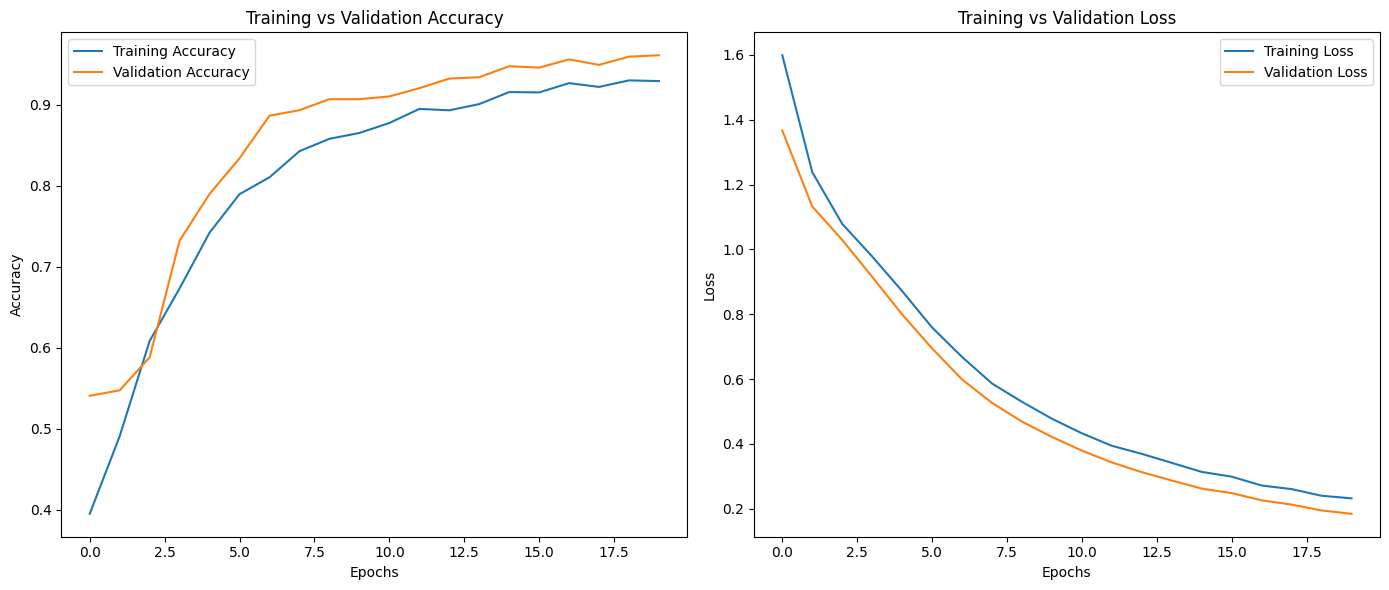

In [6]:
# Build the neural network model
model = Sequential()  # Initialize a Sequential model, where layers are added one after another

# Input Layer:
# Add a dense layer with 64 units and sigmoid activation function
# `input_dim` specifies the number of input features (columns in x_train)
model.add(Dense(units=64, kernel_initializer='normal', activation='sigmoid', input_dim=x_train.shape[1]))

# Regularization:
# Add a dropout layer to prevent overfitting by randomly setting 20% of the neurons to zero during training
model.add(Dropout(0.2))

# Output Layer:
# Add a dense layer with 6 units (number of output classes) and softmax activation function
# Softmax ensures the output values represent probabilities for multi-class classification
model.add(Dense(units=6, kernel_initializer='normal', activation='softmax'))

# Compile the model:
# - Optimizer: Adam (adaptive optimization technique, widely used)
# - Loss: Sparse Categorical Crossentropy (used for multi-class classification with integer labels)
# - Metrics: Accuracy (to evaluate model performance during training)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model's architecture to ensure it is constructed correctly
model.summary()

# Train the model:
# Train on x_train and y_train for 20 epochs with batch size 64
# Use x_test and y_test as validation data
history = model.fit(x_train, y_train, batch_size=64, epochs=20, validation_data=(x_test, y_test))

# Visualize Training and Validation Metrics
# Extract accuracy and loss values for training and validation
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Dynamically determine the number of epochs
epochs = range(len(accuracy))

# Plot Training vs Validation Accuracy
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Plot Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Show the plots
plt.tight_layout()
plt.show()


In [7]:
model   

<Sequential name=sequential_1, built=True>